

## GaussianSource

The [*GaussianSource*](https://meep.readthedocs.io/en/latest/Python_User_Interface/#gaussiansource) represents a source of electromagnetic energy shaped like the derivative of a Gaussian pulse, which ensures it has a zero mean value (zero DC component).

A **`GaussianSource`** in MEEP is your go-to tool for efficiently studying how a structure responds to a **wide range of frequencies all at once**.

While a `ContinuousSource` is like a laser pointer, emitting one pure color (a single frequency), a `GaussianSource` is like a camera flash 📸: it releases a short, brilliant pulse of energy that contains a whole spectrum of colors (many frequencies).

---

## Why a Pulse Instead of a Continuous Wave?

The main advantage is **efficiency**.

Imagine you want to measure the transmission spectrum of an optical filter—how much light it lets through at different colors.

1.  **The Slow Way (`ContinuousSource`):** You could run one simulation with a red laser, measure the result, then a new simulation with an orange laser, then yellow, and so on for every single frequency. This is extremely time-consuming.

2.  **The Fast Way (`GaussianSource`):** You can send a single, short Gaussian pulse through the filter. Since this pulse contains a wide range of frequencies, you can record the output and, with one calculation (a Fourier transform), see how the filter affected all those frequencies simultaneously.

This **broadband analysis** from a single simulation is one of the most powerful features of FDTD and MEEP.



---

## The "Gaussian" Shape: Time and Frequency

The pulse's behavior over time is what gives it its power.

* **Shape in Time:** As noted before, MEEP uses the **first derivative of a Gaussian function**. This creates a short "wiggle" that starts at zero, goes positive, then negative, and returns to zero. The key reason for this is to ensure the pulse has **zero DC offset** (no energy at frequency=0), which is physically realistic for propagating light and numerically stable.

* **Shape in Frequency:** The magic of the Fourier transform is that a Gaussian-shaped pulse in the time domain also has a **Gaussian-shaped spectrum in the frequency domain**. This means the pulse is composed of a smooth distribution of frequencies centered around a frequency you choose.

---

## Key Parameters in MEEP

When you define a `GaussianSource`, you primarily control its frequency spectrum with two parameters:

1.  **`frequency`**: This is the **center frequency** of the pulse. If you want to study how your device behaves around the color green, you set this to the frequency of green light.

2.  **`fwidth`**: This is the **frequency width** (the bandwidth). It determines how broad your spectrum is.
    * A **large `fwidth`** gives you a very wide range of frequencies. In the time domain, this corresponds to a very short, sharp pulse.
    * A **small `fwidth`** gives you a narrower, more focused range of frequencies. In the time domain, this corresponds to a longer, smoother pulse.

Here’s a simple definition:
```python
# A pulse centered at a frequency of 0.15, with a frequency width of 0.1
sources = [
    mp.Source(
        mp.GaussianSource(frequency=0.15, fwidth=0.1),
        component=mp.Ez,
        center=mp.Vector3(0, 0, 0)
    )
]


In [2]:
# inicializaci a  vystup skriptov v kapitole MEEP Sources

import meep as mp 
import matplotlib.pyplot as plt


dx = 100
dy = 100
area = mp.Vector3(dx, dy, 0)

def src_plot(dx, dy, data, res=1):
    # pomocna funkcia pre zobrazenie zdrojov v MEEP 
    # plotting 2D wave from source and wave cross section at y=50
    fig = plt.figure(figsize=(11,5))
    ax = fig.add_subplot(121)
     
    plt.imshow(data, interpolation='spline36', cmap='bwr', alpha=1.0, 
               extent=(0, dx, 0, dy), norm=plt.Normalize(-0.1, 0.1))
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid()

    ax = fig.add_subplot(122)
    plt.plot(data[50*res,:], label='Y = 50')
    plt.xlabel('X')
    plt.grid()
    plt.legend()
    plt.show()


-----------
Initializing structure...
time for choose_chunkdivision = 9.48906e-05 s
Working in 2D dimensions.


Computational cell is 100 x 100 x 0 with resolution 2
time for set_epsilon = 0.0224478 s
-----------


FloatProgress(value=0.0, description='0% done ', max=50.0)

run 0 finished at t = 50.0 (200 timesteps)


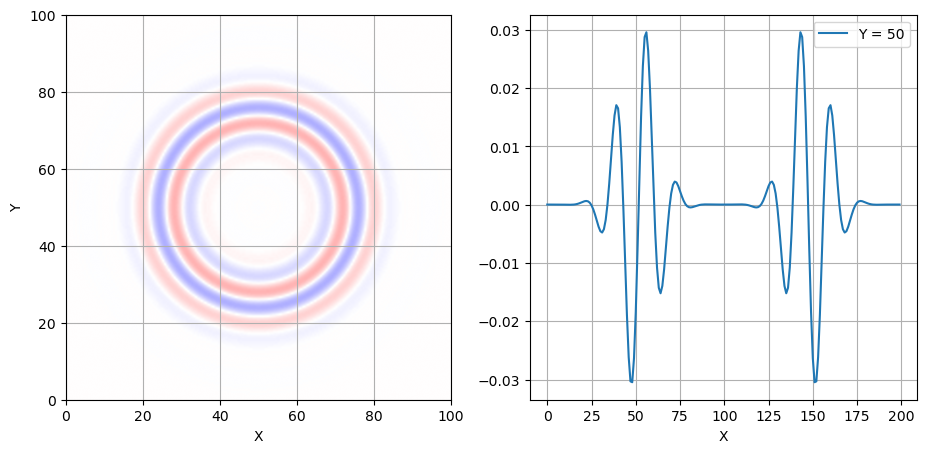

In [3]:
%matplotlib inline


sources = [ mp.Source(mp.GaussianSource(frequency=0.1, width=5),
                component=mp.Ez, 
                center=mp.Vector3(0,0,0) ) ]
                     
sim = mp.Simulation(cell_size=area, 
                boundary_layers=[mp.PML(5.0)],
                geometry=[], 
                sources=sources, 
                resolution=2)

sim.run(until=50)

data = sim.get_array(center=mp.Vector3(), 
                size=area, 
                component=mp.Ez)

src_plot(dx, dy, data.transpose(), 2)

### Animation of the Field's Time Evolution


<!-- REMOVE -->
<img src="./img/img_gauss_01.gif" >

<!-- REMOVE -->
<img src="./img/img_gauss_02.gif" >